In [2]:
# Environment setup and dataset loading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed dataset
data = np.load('data_preprocessing/dataset_v2_filtered.npy', allow_pickle=True).item()
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

# Lead names for reference
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (254, 1200, 12)
Test shape: (109, 1200, 12)


Any missing values in Train? False


C:\Users\User\AppData\Local\Temp\ipykernel_16196\632886496.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=plot_labels, y=counts, palette='viridis')


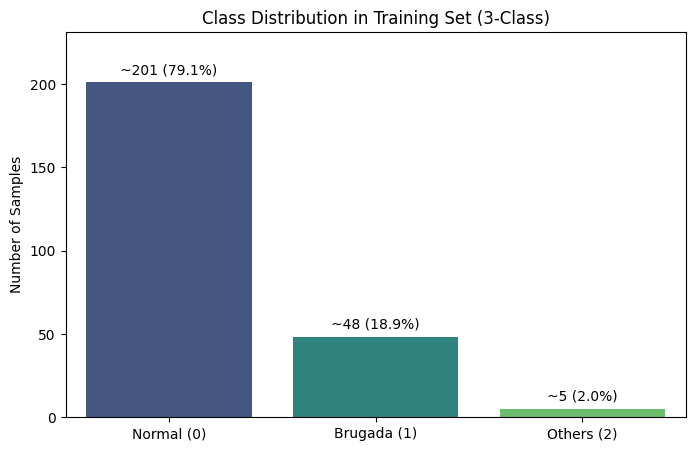

----------------------------------------
Brugada cases in Train: 48 (18.90%)
Normal to Brugada Imbalance Ratio: ~4.2:1
Insight: Significant imbalance detected. Model evaluation must prioritize
Precision-Recall curves over simple Accuracy.
----------------------------------------


In [22]:
# Data integrity check and class distribution

# Check for NaNs
print(f"Any missing values in Train? {np.isnan(X_train).any()}")

# Class Distribution
classes, counts = np.unique(y_train, return_counts=True)
total = len(y_train)

# Calculate Imbalance Ratio (Normal vs Brugada)
# This assumes classes are ordered [0, 1, 2]
imbalance_ratio = counts[0] / counts[1]

# Mapping for the chart labels
label_map = {0: 'Normal (0)', 1: 'Brugada (1)', 2: 'Others (2)'}
plot_labels = [label_map[c] for c in classes]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=plot_labels, y=counts, palette='viridis')

# Display counts and percentages on top of bars
for i, p in enumerate(ax.patches):
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f'~{count} ({percentage:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.title('Class Distribution in Training Set (3-Class)')
plt.ylabel('Number of Samples')
plt.ylim(0, max(counts) * 1.15) # Buffer for text
plt.show()

# Documenting findings
print("-" * 40)
print(f"Brugada cases in Train: {counts[1]} ({100*counts[1]/total:.2f}%)")
print(f"Normal to Brugada Imbalance Ratio: ~{imbalance_ratio:.1f}:1")
print("Insight: Significant imbalance detected. Model evaluation must prioritize")
print("Precision-Recall curves over simple Accuracy.")
print("-" * 40)

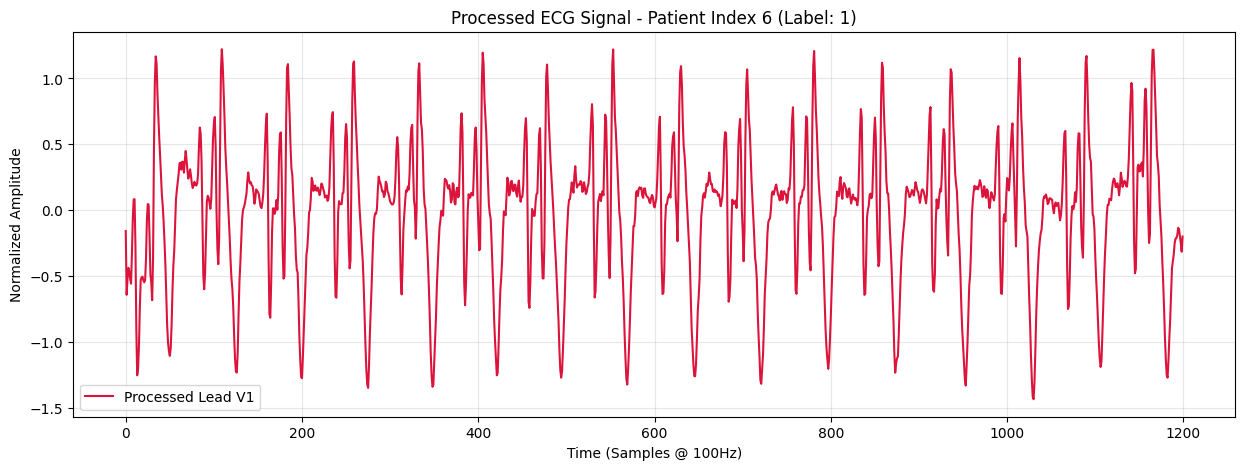

In [14]:
# Signal Quality Assessment (SQA) - Simple Visualization

def plot_signal_comparison(index, lead_idx=6): # Default to V1 (Lead 6)
    plt.figure(figsize=(15, 5))
    plt.plot(X_train[index, :, lead_idx], label=f'Processed Lead {lead_names[lead_idx]}', color='crimson')
    plt.title(f"Processed ECG Signal - Patient Index {index} (Label: {y_train[index]})")
    plt.xlabel("Time (Samples @ 100Hz)")
    plt.ylabel("Normalized Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Visualize a Brugada case (y=1)
brugada_indices = np.where(y_train == 1)[0]
plot_signal_comparison(brugada_indices[0])

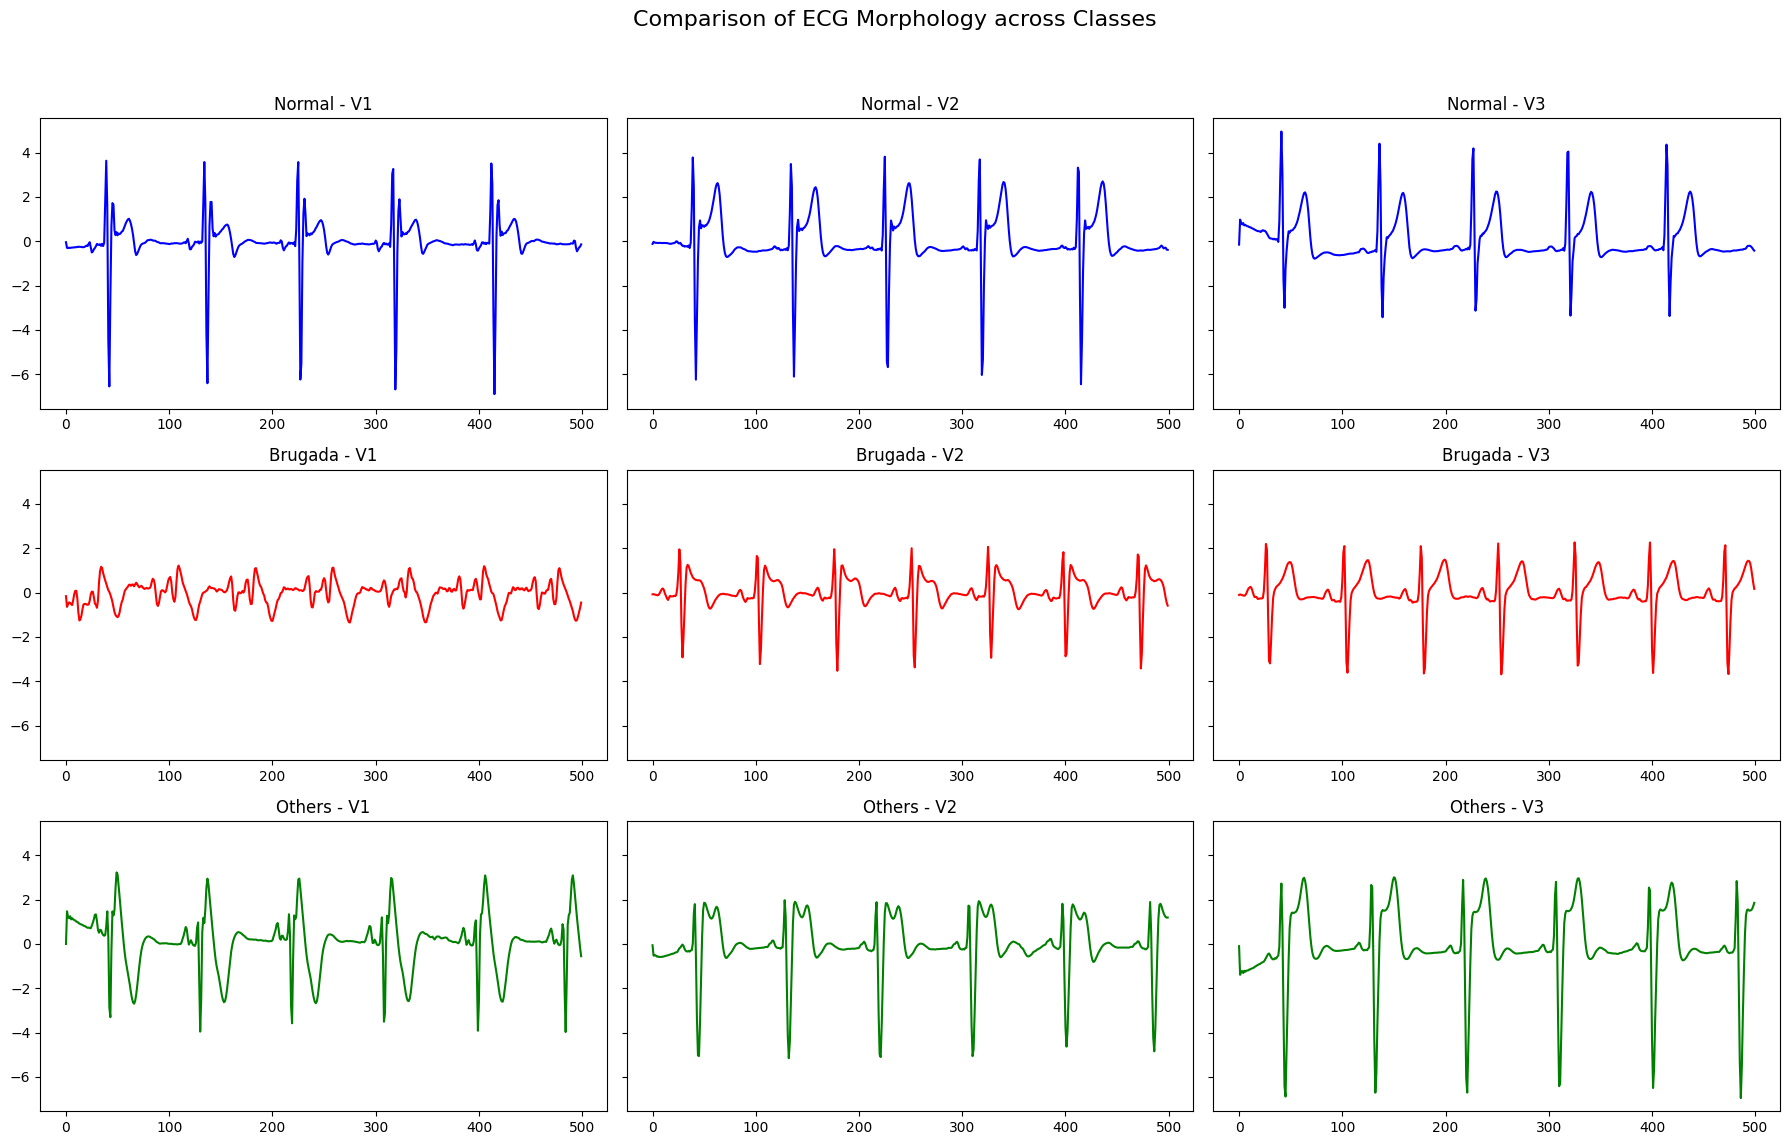

In [23]:
# Lead-level visual inspection for a Brugada case

idx_normal = np.where(y_train == 0)[0][0]
idx_brugada = np.where(y_train == 1)[0][0]
idx_others = np.where(y_train == 2)[0][0]

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharey=True)
lead_indices = [6, 7, 8] # V1, V2, V3
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

for i, l_idx in enumerate(lead_indices):
    # Row 0: Normal
    axes[0, i].plot(X_train[idx_normal, :500, l_idx], color='blue')
    axes[0, i].set_title(f'Normal - {lead_names[l_idx]}')
    
    # Row 1: Brugada
    axes[1, i].plot(X_train[idx_brugada, :500, l_idx], color='red')
    axes[1, i].set_title(f'Brugada - {lead_names[l_idx]}')
    
    # Row 2: Others
    axes[2, i].plot(X_train[idx_others, :500, l_idx], color='green')
    axes[2, i].set_title(f'Others - {lead_names[l_idx]}')

plt.suptitle("Comparison of ECG Morphology across Classes", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

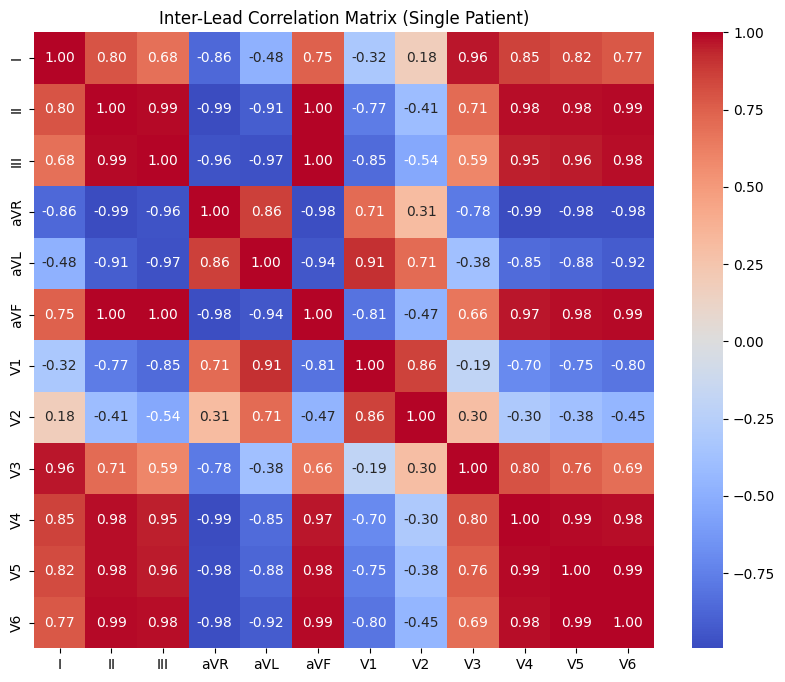

In [25]:
# Correlation analysis

# Calculate correlation matrix for the first patient's leads
corr_matrix = pd.DataFrame(X_train[0], columns=lead_names).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Inter-Lead Correlation Matrix (Single Patient)")
plt.show()

In [28]:
# Descriptive statistics for a Brugada case

# axis=(0, 1) calculates stats across all patients and all time steps for each lead
mean_amplitudes = np.mean(X_train, axis=(0, 1))
median_amplitudes = np.median(X_train, axis=(0, 1))
std_amplitudes = np.std(X_train, axis=(0, 1))
min_amplitudes = np.min(X_train, axis=(0, 1))
max_amplitudes = np.max(X_train, axis=(0, 1))

# Create a clean DataFrame for the summary
summary_df = pd.DataFrame({
    'Lead': lead_names,
    'Mean': mean_amplitudes,
    'Median': median_amplitudes,
    'StdDev': std_amplitudes,
    'Min': min_amplitudes,
    'Max': max_amplitudes
})

# Format the numbers to 4 decimal places for better readability
print("Descriptive Statistics for ECG Signal Amplitudes per Lead:")
print(summary_df.round(4).to_string(index=False))

Descriptive Statistics for ECG Signal Amplitudes per Lead:
Lead  Mean  Median  StdDev      Min     Max
   I  -0.0 -0.2035     1.0  -7.8416 13.7578
  II  -0.0 -0.1936     1.0 -13.2183 14.1358
 III   0.0 -0.1017     1.0 -18.7449 17.5941
 aVR   0.0  0.2246     1.0 -11.3902  9.1156
 aVL  -0.0 -0.0326     1.0 -13.8384 16.6205
 aVF   0.0 -0.1574     1.0 -16.1779 16.1622
  V1  -0.0  0.0840     1.0 -21.0295 19.1664
  V2  -0.0 -0.0732     1.0 -12.9891  7.8454
  V3  -0.0 -0.1527     1.0 -10.0849 10.1139
  V4  -0.0 -0.1883     1.0  -8.3291 12.1749
  V5   0.0 -0.1962     1.0 -23.3542 13.6219
  V6   0.0 -0.2001     1.0 -13.2546 23.1768
